In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
import seaborn as sns
from sklearn.metrics import silhouette_score

In [3]:
file_path = "C:/Users/benny/Documents/Repo/MLing/dataset/sensor.csv"

if os.path.exists(file_path):                  #If statement for å laste inn datasettet 
    sensor_data = pd.read_csv(file_path)       #Datasetter har navnet cement_data
    #print(cement_data.head())
else:
    print("File not found!")






#Lager ny kolonne som teller sekunder i frem til 24 timer også resetter. For å se om tidspunkt på dagen kan ha noe og si
# tidsliste = []
# while len(tidsliste) < len(sensor_data):

#     for i in range(1, 1441):
#         if len(tidsliste) < len(sensor_data):
#             tidsliste.append(i)
# sensor_data["Time"] = tidsliste



#print(sensor_data.info())
print(sensor_data.head())


print(sensor_data["sensor_00"].isnull().sum())

print(sensor_data.shape)




   NUM            timestamp  sensor_00  sensor_01  sensor_02  sensor_03  \
0    0  2018-04-01 00:00:00   2.465394   47.09201    53.2118  46.310760   
1    1  2018-04-01 00:01:00   2.465394   47.09201    53.2118  46.310760   
2    2  2018-04-01 00:02:00   2.444734   47.35243    53.2118  46.397570   
3    3  2018-04-01 00:03:00   2.460474   47.09201    53.1684  46.397568   
4    4  2018-04-01 00:04:00   2.445718   47.13541    53.2118  46.397568   

   sensor_04  sensor_05  sensor_06  sensor_07  ...  sensor_43  sensor_44  \
0   634.3750   76.45975   13.41146   16.13136  ...   41.92708  39.641200   
1   634.3750   76.45975   13.41146   16.13136  ...   41.92708  39.641200   
2   638.8889   73.54598   13.32465   16.03733  ...   41.66666  39.351852   
3   628.1250   76.98898   13.31742   16.24711  ...   40.88541  39.062500   
4   636.4583   76.58897   13.35359   16.21094  ...   41.40625  38.773150   

   sensor_45  sensor_46  sensor_47  sensor_48  sensor_49  sensor_50  \
0   65.68287   50.925

# Plots:

In [4]:
# sensor_data.isnull().sum()

# for colums in sensor_data:

#     if colums == "NUM":
#         continue
#     plot = plt.figure(figsize=(22,1), dpi=600)
#     plt.title(colums)
#     plt.plot(sensor_data["NUM"], sensor_data[colums])
#     plt.show()

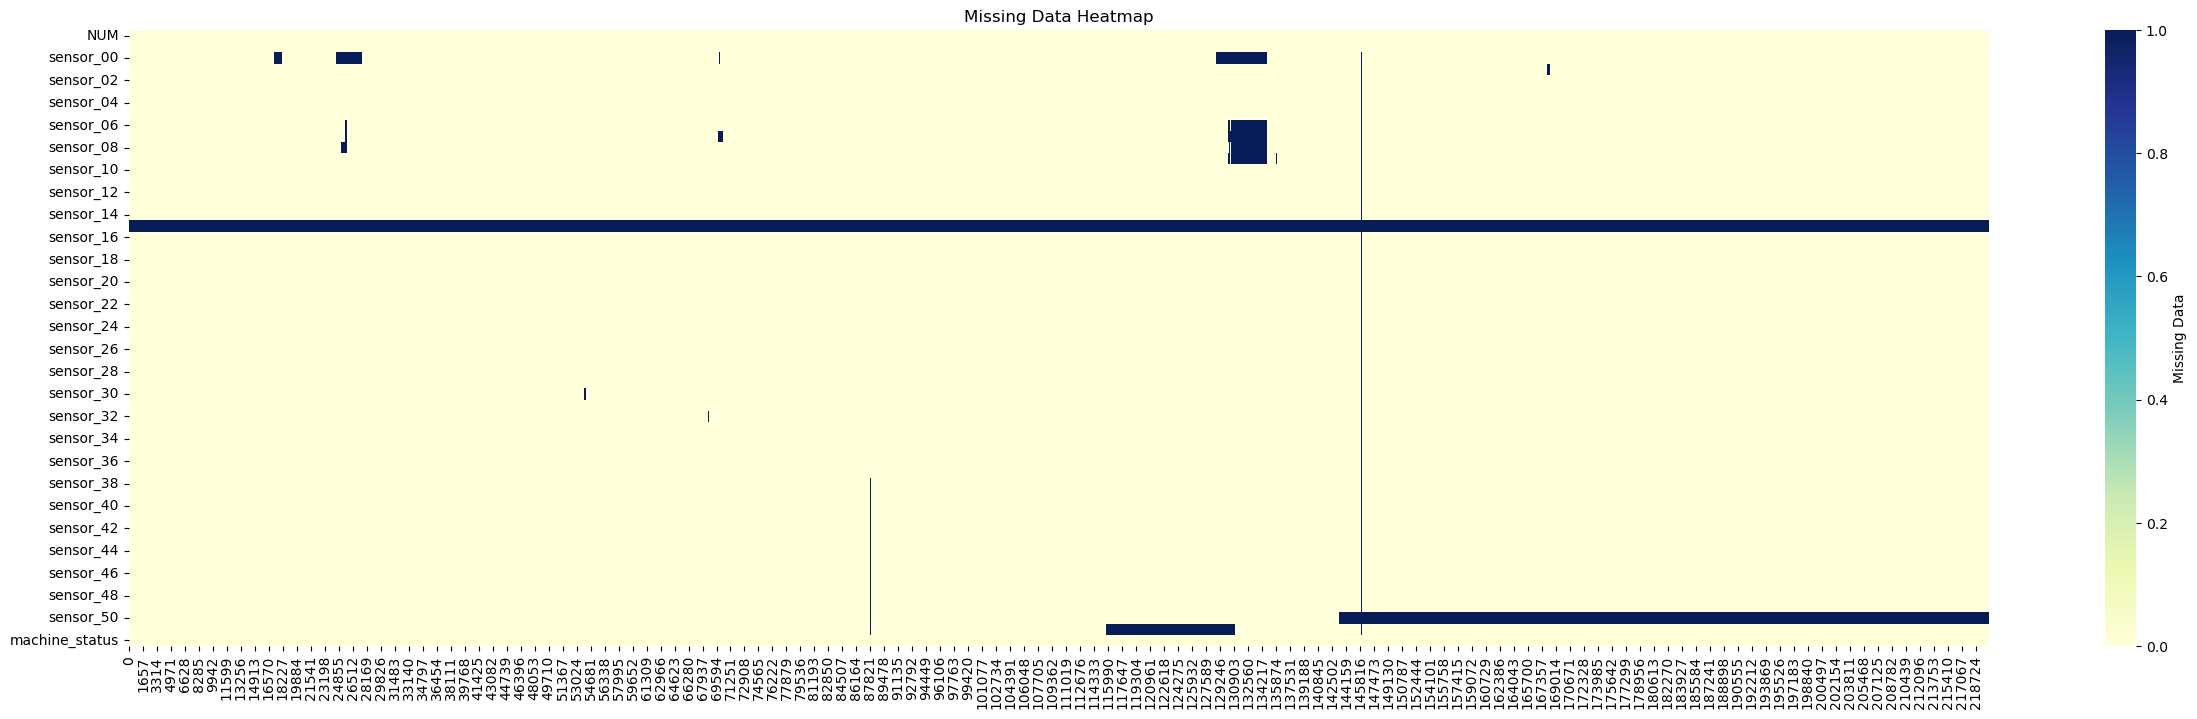

In [5]:
plt.figure(figsize=(30,8))
sns.heatmap(sensor_data.isna().transpose(),
            cmap="YlGnBu",
            cbar_kws={'label': 'Missing Data'})
plt.title('Missing Data Heatmap')
plt.show()

In [6]:
#Can se from the plot above how much data is missing from certian sensors
sensor_data = sensor_data.drop('sensor_15', axis =1) #no data here
sensor_data = sensor_data.drop('sensor_00', axis =1) #missinf a large amount
sensor_data = sensor_data.drop('NUM', axis =1)
sensor_data = sensor_data.drop('timestamp', axis =1)
sensor_data = sensor_data.drop('sensor_50', axis =1) #Missing a large amount
sensor_data = sensor_data.drop('sensor_51', axis =1) #missing a large amount

### Sensorer med høy korrelasjon med hverandre

In [7]:
sensor_data.drop(columns=["sensor_19", "sensor_18", "sensor_21", "sensor_23", "sensor_24"], axis=1,  inplace=True)

corr_matrix = sensor_data.corr()
Drop_columns = []

for colums1 in corr_matrix.columns: #Columns labels
    for colums2 in corr_matrix.index: #Index er row labels

        if colums1 != colums2 and corr_matrix.loc[colums1, colums2] >= 0.98:
            Drop_columns.append([colums1, colums2, corr_matrix.loc[colums1, colums2]])


Drop_drop = []
for set in Drop_columns: 
    for vaule in set:
        if set == set[0]:
            Drop_drop.append(vaule)
        elif set != set[0] and vaule not in Drop_drop and type(vaule) == str:
            Drop_drop.append(vaule)


print(Drop_columns)
print(Drop_drop)

#Dårlig den siste loopen. lag en mindre correlasions matrise eller fin en god måte å filtrere ut noen av sensorene som er like, kan eventuelt gjøre det for hånd. 
#deretter lag nye fetures som rolling correlation på de som er 0.95 prosent like i correlasion prøv så å legge i PCA


#             print(colums1, colums2, corr_matrix.loc[colums1, colums2] )

 

[['sensor_14', 'sensor_16', 0.9903592959221313], ['sensor_16', 'sensor_14', 0.9903592959221313], ['sensor_20', 'sensor_22', 0.9865305582651492], ['sensor_20', 'sensor_25', 0.9842401390560651], ['sensor_22', 'sensor_20', 0.9865305582651492], ['sensor_22', 'sensor_25', 0.9824827390664448], ['sensor_25', 'sensor_20', 0.9842401390560651], ['sensor_25', 'sensor_22', 0.9824827390664448]]
['sensor_14', 'sensor_16', 'sensor_20', 'sensor_22', 'sensor_25']


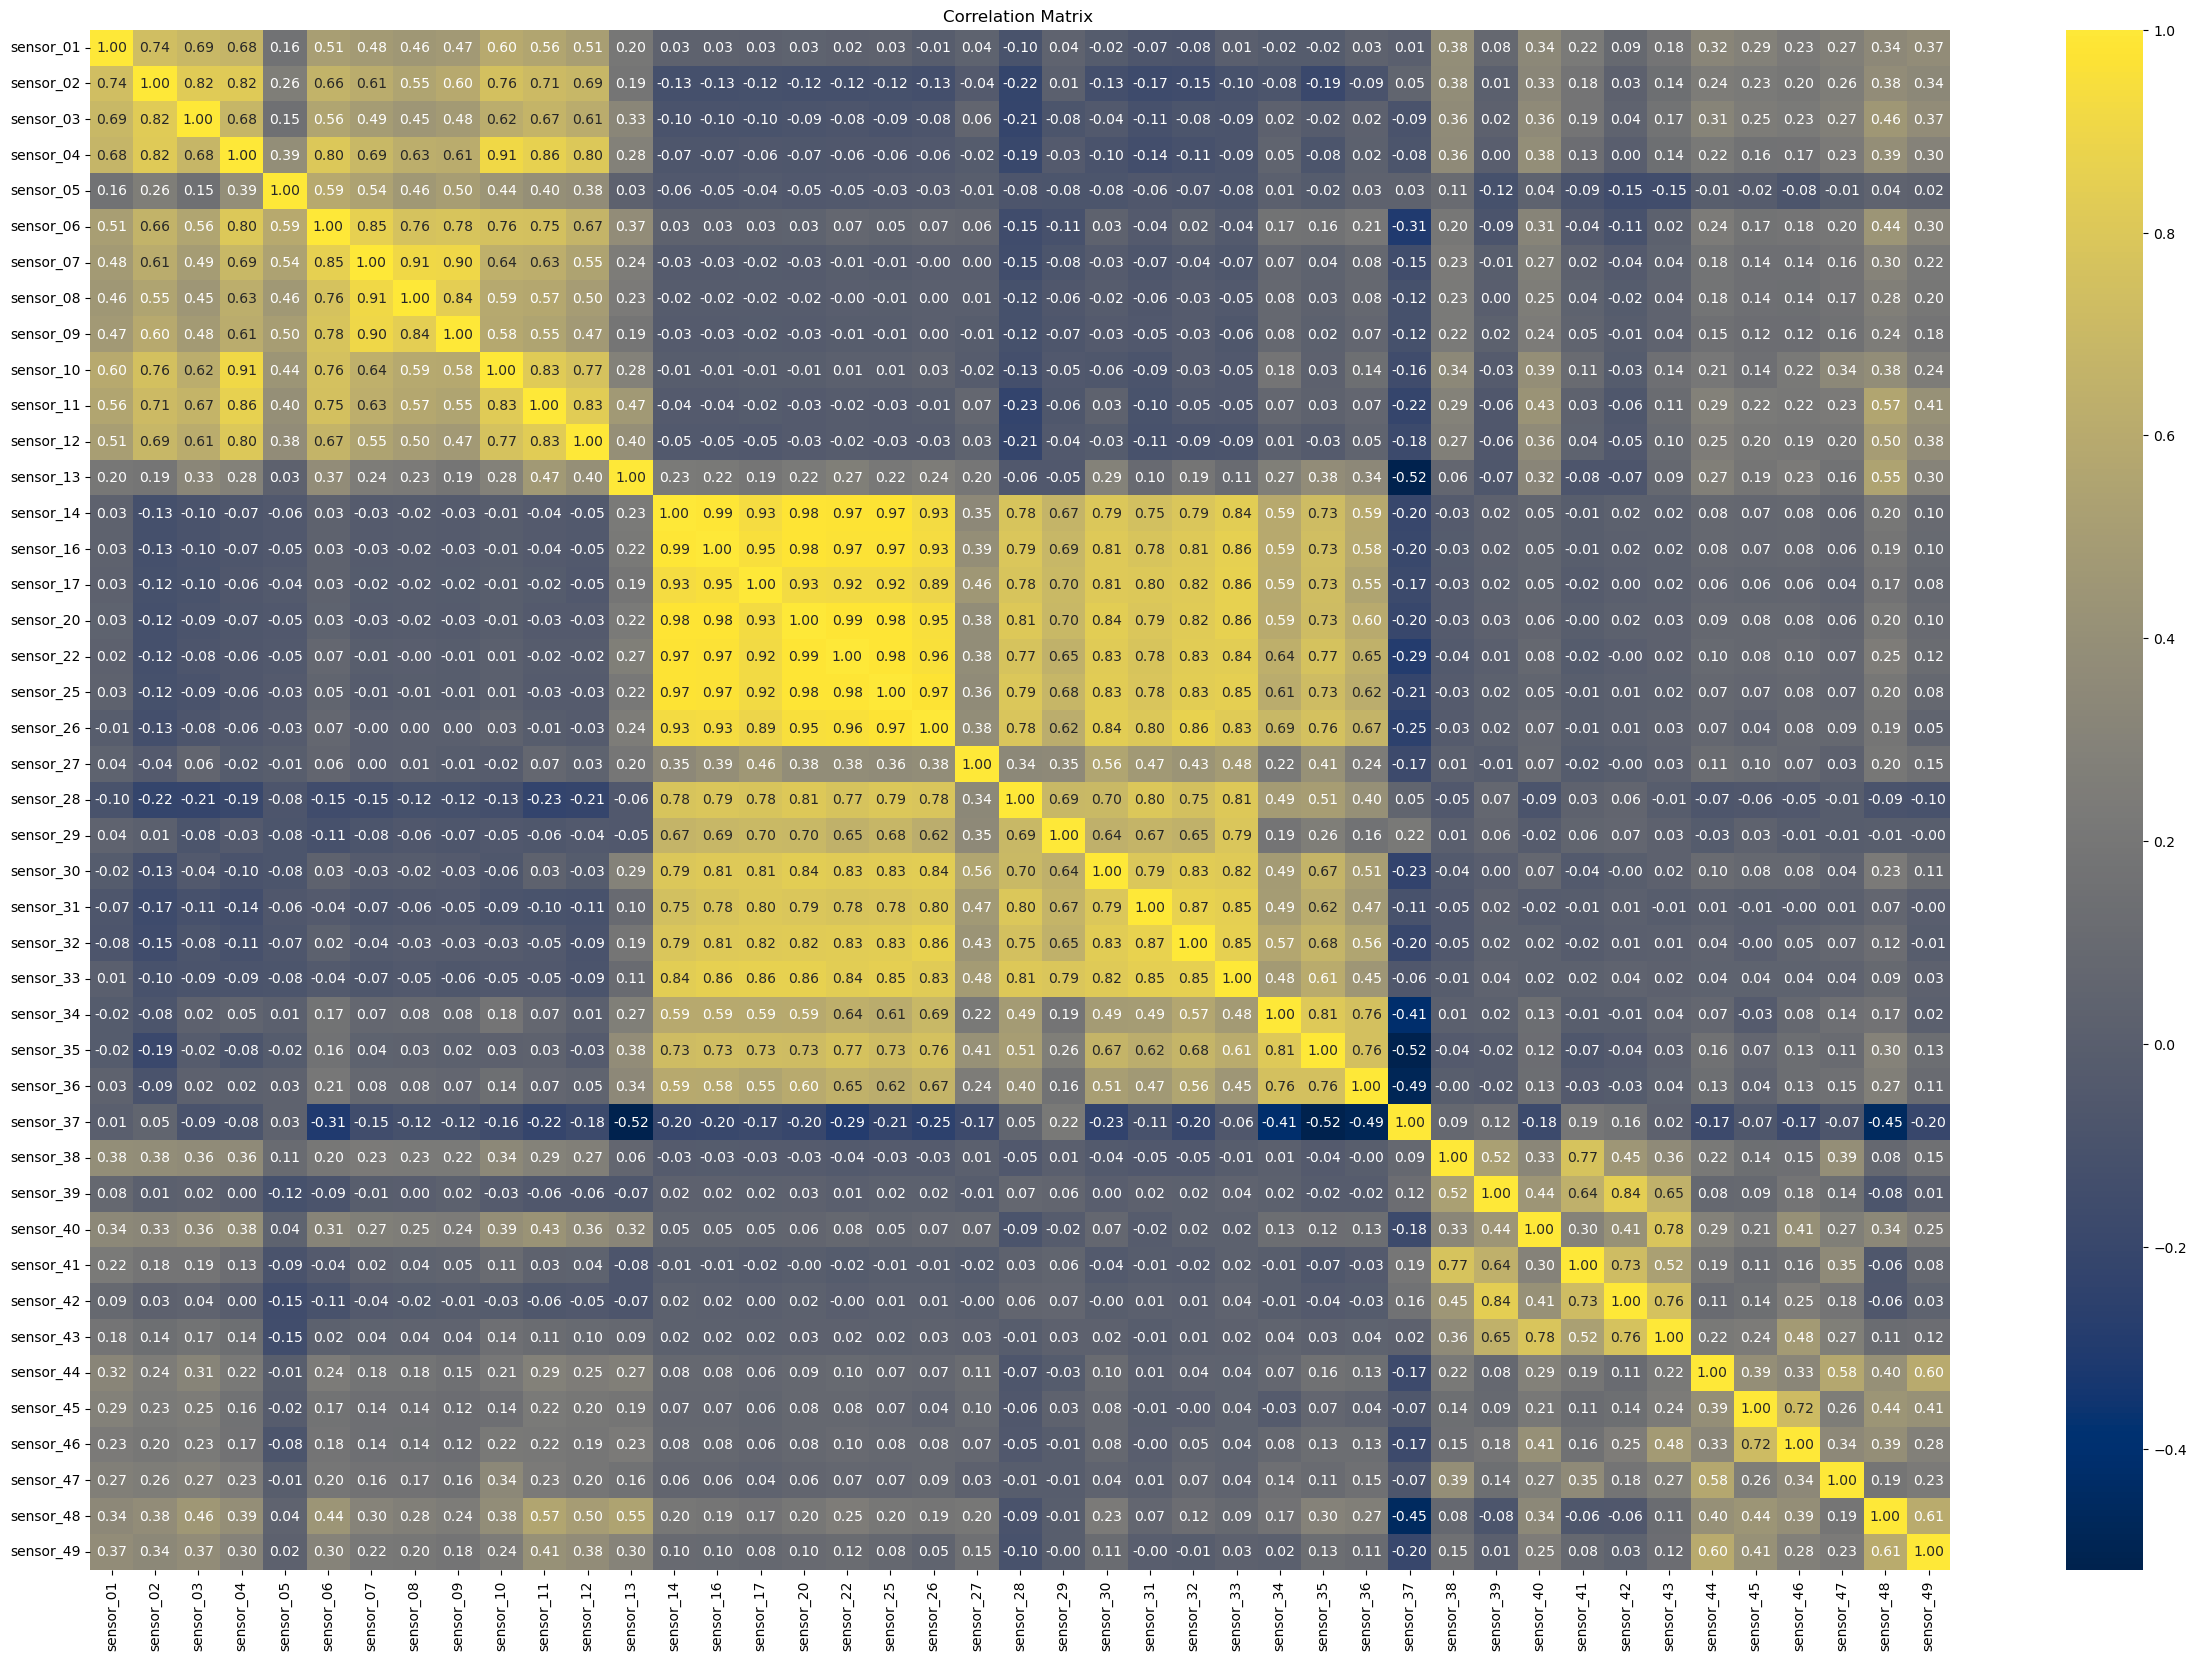

In [8]:
       
plt.figure(figsize=(30, 20))
sns.heatmap(corr_matrix, annot=True, cmap='cividis', fmt=".2f")
plt.title('Correlation Matrix ')
plt.show()

In [9]:
# sensor_data['Rolling_Corr_14_16'] = sensor_data['sensor_14'].rolling(100).corr(sensor_data['sensor_16'])
# sensor_data['Rolling_Corr_20_22'] = sensor_data['sensor_20'].rolling(100).corr(sensor_data['sensor_22'])
# sensor_data['Rolling_Corr_20_25'] = sensor_data['sensor_20'].rolling(100).corr(sensor_data['sensor_25'])
# sensor_data['Rolling_Corr_22_20'] = sensor_data['sensor_22'].rolling(100).corr(sensor_data['sensor_20'])
# sensor_data['Rolling_Corr_22_25'] = sensor_data['sensor_22'].rolling(100).corr(sensor_data['sensor_25'])


# # for colums in sensor_data:
# #     if colums[0:3] != "Rol":
# #         continue
# #     else:
# #         sensor_data[colums].fillna(method='ffill', inplace=True)
# #         plot = plt.figure(figsize=(22,1), dpi=600)
# #         plt.title(colums)
# #         plt.plot(sensor_data["NUM"], sensor_data[colums])
# #         plt.show()



# plot = plt.figure(figsize=(22,1), dpi=600)
# plt.title("Rolling_Corr_20_22")
# plt.plot(sensor_data["NUM"], sensor_data["Rolling_Corr_20_22"])
# plt.show()
# print("Before fill",sensor_data["Rolling_Corr_20_22"].isnull().sum())


# plot = plt.figure(figsize=(22,1), dpi=600)
# sensor_data["Rolling_Corr_20_22"].interpolate(method='linear', inplace=True)
# plt.title("Rolling_Corr_20_22")
# plt.plot(sensor_data["NUM"], sensor_data["Rolling_Corr_20_22"])
# plt.show()
# print("After fill",sensor_data["Rolling_Corr_20_22"].isnull().sum())

In [10]:
sensor_data.fillna(method='ffill', inplace=True)

last_40percent = round(len(sensor_data) - len(sensor_data)*.4)
train = sensor_data.iloc[ :last_40percent, :]
test = sensor_data.iloc[last_40percent: ,:]

X_cols = train.iloc[ : , 1:-1].columns
X_train = train.iloc[:,1:-1].copy()
y_train = train['machine_status']

# PCA 

In [ ]:
standard = StandardScaler()
X_train_scaled = standard.fit_transform(X_train)

pca = PCA(n_components = 0.95, svd_solver = 'full', random_state = 42 )
X_train_PCA = pca.fit_transform(X_train_scaled)



pca.explained_variance_ratio_


array([0.32366614, 0.20743987, 0.10316385, 0.05516658, 0.03636894,
       0.03420688, 0.02858396, 0.02446657, 0.02214398, 0.01980163,
       0.0168044 , 0.0158783 , 0.01296819, 0.01085597, 0.0095579 ,
       0.00836264, 0.00759448, 0.00648141, 0.00590851, 0.00566338])

# K-MIN CLUSTERING finding optimal clusters with elbow approach

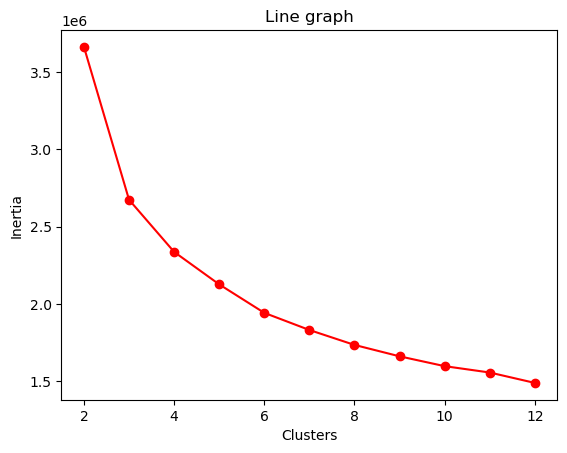

In [12]:

inertia_values = []
k_liste = []

for k in range(2, 13):
    kmeans = KMeans(n_clusters= k, random_state= 42)
    kmeans.fit(X_train_PCA)

    inertia_score = kmeans.inertia_
    inertia_values.append(inertia_score)
    k_liste.append(k)



plt.title("Line graph") 
plt.xlabel("Clusters") 
plt.ylabel("Inertia") 
plt.plot(k_liste, inertia_values , marker= "o", color ="red") 
plt.show()




c:\Users\benny\anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
c:\Users\benny\anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


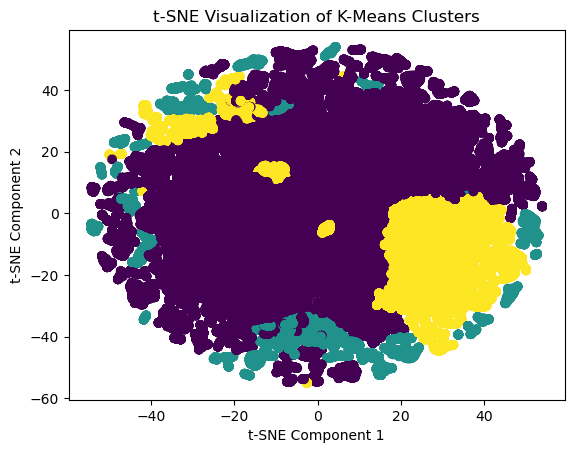

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_train_PCA)
labels = kmeans.labels_ #labeler clusterne vi har laget


tsne = TSNE(n_components=2, random_state=42) #n_components = 2 reduserer plotten vi ønsker til 2 dimensioner
vis_data = tsne.fit_transform(X_train_PCA)  # Using PCA-reduced data

plt.scatter(vis_data[:, 0], vis_data[:, 1], c=kmeans.labels_, cmap='viridis')
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization of K-Means Clusters")
plt.show()

# Silhoutte score

In [14]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_train_PCA)

# Silhouette Score
score = silhouette_score(X_train_PCA, labels)
print(f'Silhouette Score: {score:.2f}')

Silhouette Score: 0.51


#  PLOTS MED TSNE koden kjørte i 30 min funket ikke

In [15]:

# labels = gmm.predict(Dim_transform)

# tsne = TSNE(n_components=2, random_state=42) #n_components = 2 reduserer plotten vi ønsker til 2 dimensioner
# vis_data = tsne.fit_transform(Dim_transform)  # Using PCA-reduced data

# plt.scatter(vis_data[:, 0], vis_data[:, 1], c=labels, cmap='viridis')
# plt.xlabel("t-SNE Component 1")
# plt.ylabel("t-SNE Component 2")
# plt.title("t-SNE Visualization of K-Means Clusters")
# plt.show()

b = "Hello, World!"
print(b[2:5])

llo
